# Seasonal Stage 0 vs Baseline Checker
This notebook compares any two ACORN storage runs and is pre-configured for the Stage 0 seasonal test (`zone_A_seasonal_test_A0`) versus the previous seasonal experiment (`zone_A_seasonal_test_4`).

Use it to verify that the Stage 0 configuration makes the seasonal fleet behave like the base batteries before you start tightening the seasonal parameters.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid")
pd.options.display.float_format = lambda x: f"{x:,.2f}"

In [2]:
# --- User configuration -----------------------------------------------------
PROJECT_DIR = Path("/home/fs01/jl2966/acorn-julia2/acorn-julia")
RUN_NAME = "low_RE_mod_elec_iter0"
CLIMATE_SCENARIO = "historical_1980_2019"
BASE_SAVE = "zone_A_seasonal_test_4"        # baseline seasonal experiment
TEST_SAVE = "zone_A_seasonal_test_stage0_2"       # Stage 0 (seasonal behaves like base)
YEARS = None  # set e.g. [1985] to override automatic discovery

output_root = PROJECT_DIR / "runs" / RUN_NAME / "outputs" / CLIMATE_SCENARIO

def detect_years(save_name: str):
    run_dir = output_root / save_name
    return sorted({int(p.stem.split("_")[1]) for p in run_dir.glob("charge_*.csv")})

if YEARS is None:
    YEARS = sorted(set(detect_years(BASE_SAVE)) | set(detect_years(TEST_SAVE)))

print(f"Comparing years: {YEARS}")

Comparing years: [1985]


In [3]:
# --- Helper functions -------------------------------------------------------
def tidy_storage_csv(path: Path, value_name: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    meta_cols = [c for c in ["bus_id", "asset_type", "zone"] if c in df.columns]
    value_cols = [c for c in df.columns if c not in meta_cols]
    tidy = df.melt(id_vars=meta_cols, value_vars=value_cols,
                   var_name="timestamp", value_name=value_name)
    tidy["timestamp"] = pd.to_datetime(tidy["timestamp"], errors="coerce")
    tidy = tidy.dropna(subset=["timestamp"])
    return tidy

def tidy_bus_csv(path: Path, value_name: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    meta_cols = [c for c in ["bus_id", "zone"] if c in df.columns]
    value_cols = [c for c in df.columns if c not in meta_cols]
    tidy = df.melt(id_vars=meta_cols, value_vars=value_cols,
                   var_name="timestamp", value_name=value_name)
    tidy["timestamp"] = pd.to_datetime(tidy["timestamp"], errors="coerce")
    tidy = tidy.dropna(subset=["timestamp"])
    return tidy

def storage_summary_table(charge_df: pd.DataFrame, discharge_df: pd.DataFrame) -> pd.DataFrame:
    asset_types = sorted(set(charge_df["asset_type"]) | set(discharge_df["asset_type"]))
    summary = pd.DataFrame(index=asset_types)
    summary["charge_MWh"] = charge_df.groupby("asset_type")["charge"].sum()
    summary["discharge_MWh"] = discharge_df.groupby("asset_type")["discharge"].sum()
    summary = summary.fillna(0.0)
    summary["net_discharge_MWh"] = summary["discharge_MWh"] - summary["charge_MWh"]
    summary["peak_charge_MW"] = charge_df.groupby("asset_type")["charge"].max()
    summary["peak_discharge_MW"] = discharge_df.groupby("asset_type")["discharge"].max()
    summary = summary.fillna(0.0)
    totals = summary.sum().to_frame().T
    totals.index = ["TOTAL"]
    summary = pd.concat([summary, totals])
    return summary

def aggregate_timeseries(df: pd.DataFrame, value_name: str) -> pd.DataFrame:
    return (df.groupby(["asset_type", "timestamp"])[value_name]
              .sum()
              .reset_index())

In [4]:
# --- Load runs --------------------------------------------------------------
runs = {
    "baseline": BASE_SAVE,
    "stage0": TEST_SAVE,
}

run_data = {label: {} for label in runs}
run_metrics = {label: {} for label in runs}

for label, save_name in runs.items():
    run_dir = output_root / save_name
    for year in YEARS:
        charge = tidy_storage_csv(run_dir / f"charge_{year}.csv", "charge")
        discharge = tidy_storage_csv(run_dir / f"discharge_{year}.csv", "discharge")
        load_shed = tidy_bus_csv(run_dir / f"load_shedding_{year}.csv", "load_shedding")
        wind_curt = tidy_bus_csv(run_dir / f"wind_curtailment_{year}.csv", "wind_curtailment")
        solar_curt = tidy_bus_csv(run_dir / f"solar_curtailment_{year}.csv", "solar_curtailment")

        summary = storage_summary_table(charge, discharge)
        metrics = {
            "load_shed_MWh": load_shed["load_shedding"].sum(),
            "wind_curtailment_MWh": wind_curt["wind_curtailment"].sum(),
            "solar_curtailment_MWh": solar_curt["solar_curtailment"].sum(),
        }

        run_data[label][year] = {
            "charge": charge,
            "discharge": discharge,
            "load_shed": load_shed,
            "wind_curt": wind_curt,
            "solar_curt": solar_curt,
            "storage_summary": summary,
            "charge_by_type": aggregate_timeseries(charge, "charge"),
            "discharge_by_type": aggregate_timeseries(discharge, "discharge"),
        }
        run_metrics[label][year] = metrics

print("Loaded runs:")
for label in runs:
    print(f"  {label}: years -> {sorted(run_data[label].keys())}")

Loaded runs:
  baseline: years -> [1985]
  stage0: years -> [1985]


In [5]:
# --- Storage throughput comparison -----------------------------------------
for year in YEARS:
    display(Markdown(f"## Year {year} storage throughput"))
    tables = []
    for label in runs:
        tbl = run_data[label][year]["storage_summary"].copy()
        tbl = tbl.reset_index().rename(columns={"index": "asset_type"})
        tbl.insert(0, "run", label)
        tbl.insert(1, "year", year)
        tables.append(tbl)
    combined = pd.concat(tables, ignore_index=True)
    display(combined)

    pivot = combined.pivot(index="asset_type", columns="run", values="discharge_MWh")
    pivot = pivot.reindex(["base", "seasonal", "TOTAL"])
    display(Markdown("Discharge delta (stage0 - baseline)"))
    display((pivot["stage0"] - pivot["baseline"]).to_frame("delta_MWh"))

## Year 1985 storage throughput

,run,year,asset_type,charge_MWh,discharge_MWh,net_discharge_MWh,peak_charge_MW,peak_discharge_MW
0,baseline,1985,base,"12,648,087.36","11,584,625.28","-1,063,462.09","1,086.86","1,086.86"
1,baseline,1985,TOTAL,"12,648,087.36","11,584,625.28","-1,063,462.09","1,086.86","1,086.86"
2,stage0,1985,base,"4,924,928.57","3,700,638.62","-1,224,289.95","1,176.63","1,176.63"
3,stage0,1985,TOTAL,"4,924,928.57","3,700,638.62","-1,224,289.95","1,176.63","1,176.63"


Discharge delta (stage0 - baseline)

,delta_MWh
asset_type,
base,"-7,883,986.66"
seasonal,NaN
TOTAL,"-7,883,986.66"


In [6]:
# --- System metrics (load shed + curtailment) ------------------------------
metrics_rows = []
for year in YEARS:
    for label in runs:
        row = {"run": label, "year": year}
        row.update(run_metrics[label][year])
        metrics_rows.append(row)

metrics_df = pd.DataFrame(metrics_rows)
display(metrics_df)

delta = metrics_df.pivot(index="year", columns="run", values="load_shed_MWh")
if set(delta.columns) >= {"baseline", "stage0"}:
    delta["stage0_minus_baseline"] = delta["stage0"] - delta["baseline"]
    display(Markdown("### Load shedding difference (Stage0 - Baseline)"))
    display(delta)

,run,year,load_shed_MWh,wind_curtailment_MWh,solar_curtailment_MWh
0,baseline,1985,"730,692.19","4,772,278.19","5,900,996.90"
1,stage0,1985,"760,232.85","5,581,511.70","8,871,286.60"


### Load shedding difference (Stage0 - Baseline)

run,baseline,stage0,stage0_minus_baseline
year,,,
1985,"730,692.19","760,232.85","29,540.66"


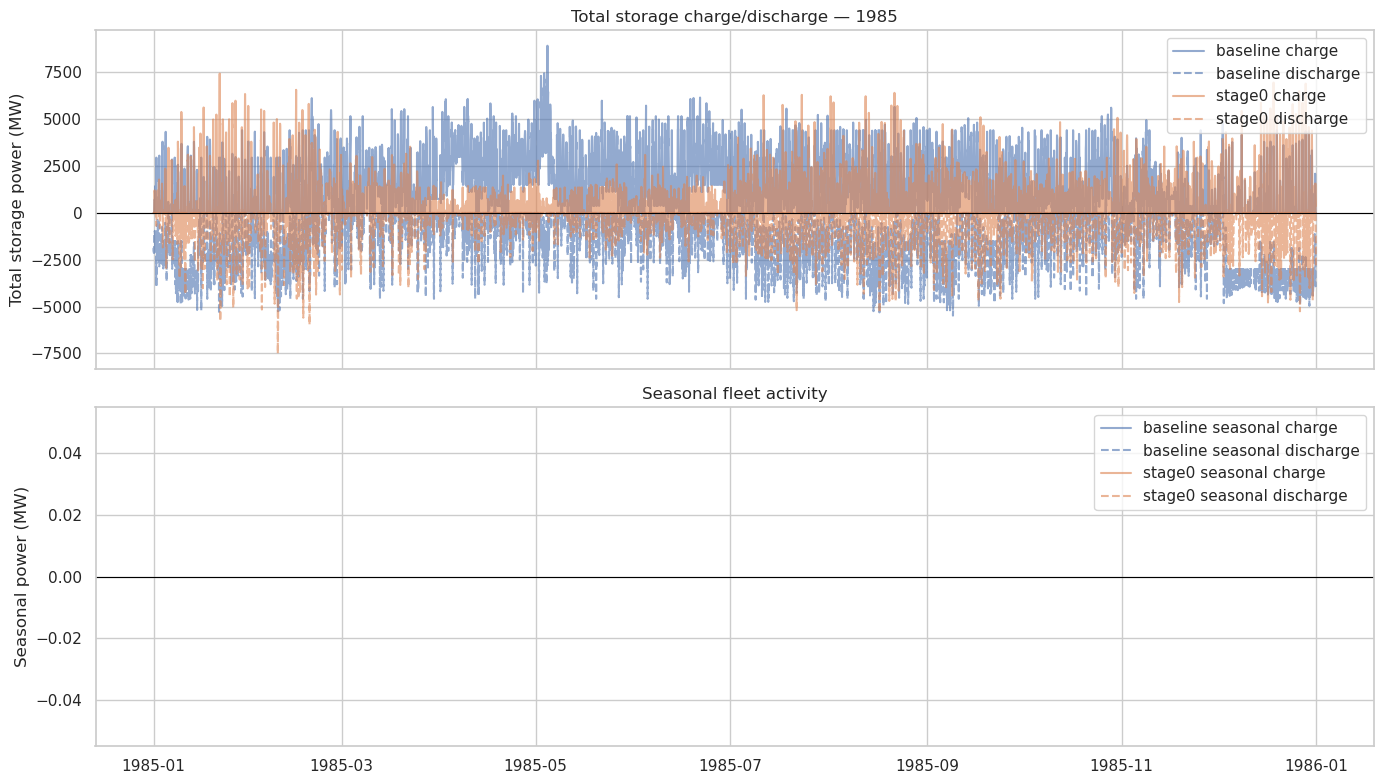

In [7]:
# --- Time-series plots -----------------------------------------------------
for year in YEARS:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    for label, color in zip(runs, ["C0", "C1"]):
        total_charge = (run_data[label][year]["charge_by_type"]
                        .groupby("timestamp")["charge"].sum())
        total_discharge = (run_data[label][year]["discharge_by_type"]
                           .groupby("timestamp")["discharge"].sum())
        axes[0].plot(total_charge.index, total_charge.values,
                    label=f"{label} charge", color=color, alpha=0.6)
        axes[0].plot(total_discharge.index, -total_discharge.values,
                    label=f"{label} discharge", color=color, linestyle="--", alpha=0.6)

        seasonal_charge = (run_data[label][year]["charge_by_type"]
                           .query('asset_type == "seasonal"')
                           .groupby("timestamp")["charge"].sum())
        seasonal_discharge = (run_data[label][year]["discharge_by_type"]
                              .query('asset_type == "seasonal"')
                              .groupby("timestamp")["discharge"].sum())
        axes[1].plot(seasonal_charge.index, seasonal_charge.values,
                    label=f"{label} seasonal charge", color=color, alpha=0.6)
        axes[1].plot(seasonal_discharge.index, -seasonal_discharge.values,
                    label=f"{label} seasonal discharge", color=color, linestyle="--", alpha=0.6)

    axes[0].axhline(0, color="black", linewidth=0.8)
    axes[0].set_ylabel("Total storage power (MW)")
    axes[0].set_title(f"Total storage charge/discharge — {year}")
    axes[0].legend(loc="upper right")

    axes[1].axhline(0, color="black", linewidth=0.8)
    axes[1].set_ylabel("Seasonal power (MW)")
    axes[1].set_title("Seasonal fleet activity")
    axes[1].legend(loc="upper right")

    plt.tight_layout()
    plt.show()

### Next steps
- If Stage 0 seasonal charge/discharge lines align with the baseline `base` fleet, you have successfully mimicked the original batteries.
- Re-run the notebook after toggling `--seasonal_rate_caps_on` or changing SOC floors to see how utilization, load shedding, and curtailment respond.
- Extend the metrics block with additional diagnostics (e.g., monthly SOC swing) as you explore multi-month behavior.